<div style="padding: 15px; border: 1px solid #003152; border-radius: 5px; background-color: #fff5ef; color: #003152;">

**Project:** When Weight Doesn’t Weigh the same on Everyone: Applying The Lancet’s Clinical Obesity Framework to Map Phenotypic Diagnostic Gaps in NHANES 2021–2023  
**Source:** National Health and Nutrition Examination Survey (NHANES), Aug 2021–Aug 2023 Cycle  
**Key Transformation:** Row Attrition and Structural Selection Bias Mitigation  
**Version:** 1.0  

---
**Technical Focus:** Extraction, harmonization, and systemic alignment of multi-tiered CDC survey files. It implements an intentional flagging pipeline ($N=11,933 \to 1,955$) that isolates working-age adults while controlling for non-random structural missingness  
**Key Goal:** Eradicate structural missingness and establish a foundational cohort for epidemiological modeling.

</div>

In [41]:
from IPython.display import display, Markdown, HTML
import os
import pyreadstat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import missingno as msno
import pyarrow

## 🧪 Clinical Parameters ingestion
---

Implementing *The Lancet Diabetes & Endocrinology* Commission consensus framework on clinical obesity ([The Lancet, 2025](https://www.thelancet.com/journals/landia/article/PIIS2213-8587%2824%2900316-4/fulltext)) requires moving past single metrics like BMI. To evaluate the diverse spectrum of obesity, our ingestion pipeline organizes disparate survey data into four primary clinical domains:

1.  **Demographics and Baselines:** Baseline anthropometric parameters and vital physical exam variables.
2.  **Laboratory Biomarkers:** Blood-derived metabolic analytes, such as lipid profiles, glycohemoglobin, fasting plasma glucose, and hepatic transaminases.
3.  **End-Organ Damage & Comorbidities:** Key patient history markers for cardiovascular disease, liver conditions, chronic kidney disease, and diabetic diagnostic states.
4.  **Questionnaire-Related Items:** Extracting patient-reported behavioral inputs such as active smoking status.

In [42]:
class Loader:
    """
    Pipeline class to batch-load, type-standardize, and consolidate NHANES SAS Transport (.XPT) files 
    into an unified cohort.
    """

    def __init__(self, target_files=None, data_folder="../sources/"):
        self.data_folder = data_folder
        self.target_files = target_files or [
            "DEMO_L", "BMX_L", "LUX_L", "ALB_CR_L", "HDL_L", "TRIGLY_L", "TCHOL_L", "CBC_L", "GHB_L", "GLU_L", 
            "BIOPRO_L", "BPQ_L", "BPXO_L", "DIQ_L", "KIQ_U_L", "SMQ_L", "MCQ_L", "DPQ_L", "RXQ_RX_L", "PAQ_L"
        ]

        # Core data structures to store state
        self.loaded_datasets = {}  # Map: file_prefix -> DataFrame
        self.metadata_storage = {} # Map: file_prefix -> column_labels dict
        self.master_df = None

    def batch_load(self, encoding="latin1"):
        """
        Read local .xpt files, standardizes patient IDs, and stores metadata maps.
        """

        print("Starting batch-loading pipeline...")
        
        for file_prefix in self.target_files:
            file_name = f"{file_prefix}.xpt"
            file_path = os.path.join(self.data_folder, file_name)
                
            if os.path.exists(file_path):
                print(f"Reading local: {file_name}")
                df, meta = pyreadstat.read_xport(file_path, encoding=encoding)
                
                # Standardize SEQN (Respondent Sequence Number) for flawless multi-table joins
                if 'SEQN' in df.columns:
                    df['SEQN'] = df['SEQN'].astype(int)
                
                self.loaded_datasets[file_prefix] = df
                self.metadata_storage[file_prefix] = meta.column_names_to_labels
            else:
                print(f"Warning: File {file_name} not found in {self.data_folder}")
        
        return self
    
    def consolidate(self, anchor_file="DEMO_L"):
        """
        Execute a sequential left join anchored on demographics to preserve baseline data 
        and handle duplicate columns via safe source-specific suffixes.
        """
        if not self.loaded_datasets:
            raise ValueError("Execution Error: No dataframes have been loaded into memory yet.")
        
        if anchor_file not in self.loaded_datasets:
            raise KeyError(f"Critical Error: Anchor file '{anchor_file}' was not successfully loaded.")

        print(f"\nConsolidating cohorts... Anchoring on baseline demographics: {anchor_file}")
        
        # Initialize master cohort dataframe with baseline demographics
        self.master_df = self.loaded_datasets[anchor_file]

        # Iterate through remaining loaded files safely using dictionary key mapping
        for file_prefix, df in self.loaded_datasets.items():
            if file_prefix == anchor_file:
                continue
            
            # Left join ensures no loss of baseline demographic rows due to missing secondary files
            self.master_df = pd.merge(
                self.master_df, 
                df, 
                on='SEQN', 
                how='left', 
                suffixes=('', f'_{file_prefix}') # Prevents naming collisions by appending _FILENAME to duplicates
            )

        print(f"Success! Consolidated Master Cohort Shape: {self.master_df.shape}")
        return self.master_df

In [43]:
class Selector:

    def __init__( self,  dataframe, target_columns=None):
        self.selected_df = dataframe.copy()

        self.target_columns = target_columns or [
            # Stratification-related variables
            "SDMVSTRA", "SDMVPSU", "WTSAF2YR", "WTMEC2YR", "WTPH2YR",
            
            # Demographics and baseline parameters
            "SEQN", "RIDEXPRG", "RIDAGEYR", "RIAGENDR", "RIDRETH3", "BMXBMI", "BMXWAIST", "BMXWT", "BMXHIP", "BMXHT",
            "BPXOSY1","BPXODI1", "BPXOSY2","BPXODI2", "BPXOSY3", "BPXODI3", "BPXOPLS1", "BPXOPLS2", "BPXOPLS3",

            # Laboratory data
            "LBDHDD", "LBXTLG", "LBDLDL", "LBXTC", "LBXPLTSI", "LBXGH", "LBXGLU", "LBXSATSI", "LBXSASSI",
            "LBXSCR", "LBXSGTSI", 

            # Questionnaire items
            "SMQ020", "SMQ040", "PAD680",

            # End-organ damage
            "LUXSMED", "URXUMA", "URDACT",

            # Chronic diseases
            "BPQ020", "BPQ150", "MCQ160B", "MCQ160C", "MCQ160D", "MCQ160E", "MCQ160F", "BPQ080", "BPQ101D", 
            "DIQ010", "DIQ050", "DIQ070", "MCQ160L", "MCQ510A", "MCQ510B", "KIQ022", "KIQ025", "RXQ033",
            "RXQ050", "DIQ160"
        ]
    
    def select_features(self):
        """
        Safely isolates specified target columns.
        """
        valid_cols = [col for col in self.target_columns if col in self.selected_df.columns]
        missing_cols = [col for col in self.target_columns if col not in self.selected_df.columns]
        
        dropped_count = len(self.target_columns) - len(valid_cols)
        if dropped_count > 0:
            print(f"Note: {dropped_count} columns requested were missing from input and skipped.")
            for col in missing_cols:
                print(col)
            print("")

        self.selected_df = self.selected_df[valid_cols]
        return self
    
    def get_data(self):
        """
        Terminator method to break out of the chain and deliver the resulting DataFrame.
        """
        return self.selected_df

In [44]:
class Processor:
    """
    Handles column selection, row-level filtration, and cohort isolation based on data completeness
    """

    def __init__( self,  dataframe, target_columns=None):
        self.processed_df = dataframe.copy()
    
    def inclusion_criteria(self):
        """
        Execute clinical inclusion rules. 
        """
        initial_rows = self.processed_df.shape[0]

        # Include ages >=18 and <65 years old
        self.processed_df["target_age"] = np.where(
            (self.processed_df["RIDAGEYR"] >= 18) & 
            (self.processed_df["RIDAGEYR"] < 65), 1, 0).astype(bool)
        
        # Include required variables that do not have empty values
        self.processed_df["target_variables"] = np.where(
            (self.processed_df["BMXBMI"].notna()) &
            (self.processed_df["BMXWAIST"].notna()) &
            (self.processed_df["BMXHIP"].notna()) &
            (self.processed_df["BMXHT"].notna()) &
            (self.processed_df["LBDHDD"].notna()) &
            (self.processed_df["LBXTLG"].notna()) &
            (self.processed_df["LBDLDL"].notna()) &
            (self.processed_df["LBXTC"].notna()) &
            (self.processed_df["LBXPLTSI"].notna()) &
            (self.processed_df["LBXGH"].notna()) &
            (self.processed_df["LBXGLU"].notna()) &
            (self.processed_df["LBXSATSI"].notna()) &
            (self.processed_df["LBXSASSI"].notna()) &
            (self.processed_df["LBXSCR"].notna()) &
            (self.processed_df["LBXSGTSI"].notna()) &
            (self.processed_df["BPQ150"].notna()) &
            (self.processed_df["DIQ010"].notna()) &
            (self.processed_df["SMQ040"].notna()), 1, 0).astype(bool)

        # Filter for complete inclusion criteria
        self.processed_df["cohort"] = np.where(
            (self.processed_df["WTSAF2YR"].notna()) &
            (self.processed_df["RIDEXPRG"] != 1) &
            (self.processed_df["target_age"] == 1) &
            (self.processed_df["target_variables"] == 1), 1, 0).astype(bool)
    
        # Return row attrition per criteria
        print(f"Starting rows: {initial_rows} active records.")

        # 1. Fasting weight exclusion (First step)
        dropped_fasting = self.processed_df['WTSAF2YR'].isna().sum()
        print(f"Exclusion [Fasting]: Dropped {dropped_fasting} active records.")

        # 2. Pregnancy exclusion (Only out of those who have a valid fasting weight)
        dropped_pregnancy = ((self.processed_df['WTSAF2YR'].notna()) & 
                            (self.processed_df['RIDEXPRG'] == 1)).sum()
        print(f"Exclusion [Pregnancy]: Dropped {dropped_pregnancy} active records.")

        # 3. Age boundaries exclusion (Only out of those who have valid weight AND are not pregnant)
        dropped_age = ((self.processed_df['WTSAF2YR'].notna()) & 
               (self.processed_df['RIDEXPRG'] != 1) & 
               (self.processed_df['target_age'] == 0)).sum()
        print(f"Exclusion [Age boundaries]: Dropped {dropped_age} active records.")

        # Non-empty variables 
        dropped_variables = ((self.processed_df['WTSAF2YR'].notna()) & 
                    (self.processed_df['RIDEXPRG'] != 1) & 
                    (self.processed_df['target_age'] == 1) &
                    (self.processed_df["target_variables"] == 0)).sum()
        print(f"Exclusion [Missing variables]: Dropped {dropped_variables} active records.")

        # Final Count
        final_cohort_size = self.processed_df['cohort'].sum()
        print(f"Final Cohort Size: {final_cohort_size} active records.")

        return self
    
    def get_data(self):
        """
        Terminator method to break out of the chain and deliver the resulting DataFrame.
        """
        return self.processed_df

In [45]:
class Auditor:
    """
    Evaluate data completeness patterns and map raw variable codes to human-readable clinical labels.
    """

    def __init__(self, dataframe, metadata_storage=None):
        # Create a copy to protect the upstream DataFrame from accidental mutations
        self.df = dataframe.copy()
        self.master_label_map = {}

        # Safely flatten NHANESLoader's metadata_storage into a single dictionary during instantiation
        if metadata_storage:
            for file_prefix, labels in metadata_storage.items():
                self.master_label_map.update(labels)

    def column_missingness(self, head_count=15):
        # Calculate absolute missingness and percentage across the dataset
        missing_counts = self.df.isnull().sum()
        missing_percentages = (self.df.isnull().mean() * 100)

        # Consolidate into an audit DataFrame
        missing_report = pd.DataFrame({
            "Missing_Count": missing_counts,
            "Missing_Percentage": missing_percentages
        }).sort_values(by="Missing_Percentage", ascending=False)

        # Restructure index and map structural clinical labels
        missing_report = missing_report.reset_index().rename(columns={"index": "Variable_Code"})
        missing_report["Clinical_Label"] = missing_report["Variable_Code"].map(self.master_label_map)

        # Reorder columns for readability
        missing_report = missing_report[["Variable_Code", "Clinical_Label", "Missing_Count", "Missing_Percentage"]]

        display(missing_report.head(head_count))

    def visualize_nullity(self, target_columns=None):
        """
        Forensic Audit: Visualizing data deserts to evaluate mission-specific documentation constraints.
        
        Parameters:
        - target_columns (list): Specific columns to visualize. If None, plots all columns.
        """

        # Dynamically map the target list
        if target_columns is None:
             target_columns = self.df.columns.tolist()
                
        available_keys = [v for v in target_columns if v in self.df.columns]
        unavailable_keys = [v for v in target_columns if v not in self.df.columns]
        
        if not available_keys:
            print("Warning: None of the specified target columns were found in the dataset.")
            return self
        
        if unavailable_keys:
            dropped_count = len(unavailable_keys)
            print(f"Note: {dropped_count} columns requested were missing from input and skipped.")
            for col in unavailable_keys:
                print(col)

        print("Missingness Visualizations\n" + '-' * 40)
        
        with plt.style.context('default'):
            plt.figure(figsize=(10, 6))
            msno.matrix(
                self.df[available_keys], 
                sparkline=False, 
                color=mcolors.to_rgb('#2c3e50'), # Maintains your signature dark blue hex
                fontsize=10
            )
            plt.title("Nullity Matrix: Data Presence (Dark) vs Missing (White)", fontsize=14)
            plt.show()
            
        return self

In [46]:
class Imputer:
    def __init__(self, dataframe):
        # Create a copy to protect the upstream DataFrame from accidental mutations
        self.df = dataframe.copy()

    def structural_skips(self):
        """
        Executes explicit, deterministic imputation on structurally missing 
        child features by leveraging their respective gatekeeper clinical parent variables.
        """
        # Define the structural skip ledger: { Parent_Column: { Non_Trigger_Values: [Child_Columns], Default_Impute_Value } }
        structural_map = {
            "SMQ020": {
                "trigger_values": [2.0],            # 2.0 = Answered "No" to smoking 100+ cigarettes
                "children": ["SMQ040"],
                "impute_val": 3.0                   # 3.0 = "Not at all" (Non-smoker)
            },
            "BPQ020": {
                "trigger_values": [2.0],            # 2.0 = "No" to high blood pressure history
                "children": ["BPQ150"],             # BPQ150 = "Taking medicine for high BP"
                "impute_val": 2.0                   # 2.0 = "No"
            },
            "DIQ010": {
                "trigger_values": [2.0, 3.0],       # 2.0 = No, 3.0 = Borderline/Prediabetes
                "children": ["DIQ050", "DIQ070"],   # Insulin, Oral diabetic agents
                "impute_val": 2.0                   # 2.0 = "No"
            },
            "MCQ160L": {
            "trigger_values": [2.0],                # 2.0 = "No" to ever having a liver condition
            "children": ["MCQ510A", "MCQ510B"],     # Fatty liver, Liver fibrosis flags
            "impute_val": 0.0                       # 0.0 = Absence of specified condition
            },
            "KIQ022": {
                "trigger_values": [2.0],            # 2.0 = "No" to kidney failure history
                "children": ["KIQ025"],             # KIQ025 = Dialysis in past 12 months
                "impute_val": 2.0                   # 2.0 = "No"
            }
        }

        # Iterate dynamically over the clinical variable
        for parent, meta in structural_map.items():
            if parent in self.df.columns:
                # Locate rows where parent is valid and falls under non-trigger categories
                parent_mask = self.df[parent].isin(meta["trigger_values"])

                for child in meta["children"]:
                    if child in self.df.columns:
                        # Capture rows that are currently NaN before imputation for auditing
                        null_before = self.df[child].isna().sum()

                        # Apply deterministic imputation to the structural missing values
                        self.df.loc[parent_mask & self.df[child].isna(), child] = meta["impute_val"]

                        null_after = self.df[child].isna().sum()
                        print(f"Imputation [{parent} -> {child}]: Rescued {null_before - null_after} structural records.")
                    else:
                        print(f"Note: Child column '{child}' missing from matrix context. Skipping.")
            else:
                print(f"Warning: Parent gatekeeper '{parent}' not found in DataFrame slice.")

        return self.df

In [47]:
# Instantiate the data pipeline loader
loader = Loader()

# Method chaining: Load data locally and then build the master cohort 
master_dataset = loader.batch_load().consolidate()

Starting batch-loading pipeline...
Reading local: DEMO_L.xpt
Reading local: BMX_L.xpt
Reading local: LUX_L.xpt
Reading local: ALB_CR_L.xpt
Reading local: HDL_L.xpt
Reading local: TRIGLY_L.xpt
Reading local: TCHOL_L.xpt
Reading local: CBC_L.xpt
Reading local: GHB_L.xpt
Reading local: GLU_L.xpt
Reading local: BIOPRO_L.xpt
Reading local: BPQ_L.xpt
Reading local: BPXO_L.xpt
Reading local: DIQ_L.xpt
Reading local: KIQ_U_L.xpt
Reading local: SMQ_L.xpt
Reading local: MCQ_L.xpt
Reading local: DPQ_L.xpt
Reading local: RXQ_RX_L.xpt
Reading local: PAQ_L.xpt

Consolidating cohorts... Anchoring on baseline demographics: DEMO_L
Success! Consolidated Master Cohort Shape: (11933, 243)


In [48]:
# Column selection
selected_columns = (
    Selector(master_dataset)
    .select_features()
    .get_data()
)

## 🔍 Missingness Topology & The Logic of Structural Skips
---
To preserve real-world data (RWD) provenance, we perform a detailed missingness audit across our variables. Missing data falls into two distinct categories:

1.  **Fasting Non-Response:** Large missing blocks across laboratory variables like fasting glucose. This is a direct consequence of the survey's fasting subsample design, handled by using the correct fasting weights (`WTSAF2YR`).
2.  **Logical Structural Skips:** Sharp, horizontal white lines for variables like anti-hypertensive medication usage (`BPQ150`), insulin administration (`DIQ050`), and smoking details (`SMQ040`).

These skipped entries are not random. Instead, they are directed by parent "gatekeeper" questions. For example, if a patient answers "No" to ever having high blood pressure (`BPQ020 = 2.0`), the survey skips the follow-up question regarding blood pressure medications (`BPQ150`). Treating these skipped responses as missing values leads to statistical bias and unnecessary row loss.

In [49]:
# Instantiate the audit engine by explicitly passing your data and loader metadata
auditor = Auditor(selected_columns, metadata_storage=loader.metadata_storage)

# Run the execution layer and capture the full dataframe output
missing_data_summary = auditor.column_missingness(head_count=20)


,Variable_Code,Clinical_Label,Missing_Count,Missing_Percentage
0,MCQ510B,Liver condition: Liver fibrosis,11929,99.966480
1,MCQ510A,Liver condition: Fatty liver,11673,97.821168
2,KIQ025,Received dialysis in past 12 months?,11612,97.309981
3,DIQ050,Taking insulin now,10852,90.941088
4,RIDEXPRG,Pregnancy status at exam,10430,87.404676
5,DIQ070,Take diabetic pills to lower blood sugar,9652,80.884941
6,BPQ150,Taking high blood pressure medication,8964,75.119417
7,SMQ040,Do you now smoke cigarettes?,8690,72.823263
8,LBDLDL,"LDL-Cholesterol, Friedewald (mg/dL)",8453,70.837174
9,LBXTLG,Triglyceride (mg/dL),8416,70.527110


In [50]:
demographics = [
    # Respondent Sequence Number (SEQN) as control
    "SEQN",

    # Demographics and baseline parameters
    "RIDAGEYR", "RIAGENDR", "RIDRETH3", "BMXBMI", "BMXWAIST", "BMXWT", "BMXHIP", "BMXHT",
    "BPXOSY1","BPXODI1", "BPXOSY2","BPXODI2", "BPXOSY3", "BPXODI3","BPXOPLS1", "BPXOPLS2", "BPXOPLS3",
]

labs_questions = [
    # Respondent Sequence Number (SEQN) as control
    "SEQN",

    # Laboratory data
    "LBDHDD", "LBXTLG", "LBDLDL", "LBXTC", "LBXPLTSI", "LBXGH", "LBXGLU", "LBXSATSI", "LBXSASSI",
    "LBXSCR", "LBXSGTSI", 

    # Questionnaire items
    "SMQ020", "SMQ040", "PAD680",
]

organ_damage = [
    # Respondent Sequence Number (SEQN) as control
    "SEQN",
    
    # End-organ damage
    "LUXSMED", "URXUMA", "URDACT",

    # Chronic diseases
    "BPQ020", "BPQ150", "MCQ160B", "MCQ160C", "MCQ160D", "MCQ160E", "MCQ160F", "BPQ080", "BPQ101D", 
    "DIQ010", "DIQ050", "DIQ070", "MCQ160L", "MCQ510A", "MCQ510B", "KIQ022", "KIQ025", "RXQ033",
    "RXQ050", "DIQ160"
]

Missingness Visualizations
----------------------------------------


<Figure size 1000x600 with 0 Axes>

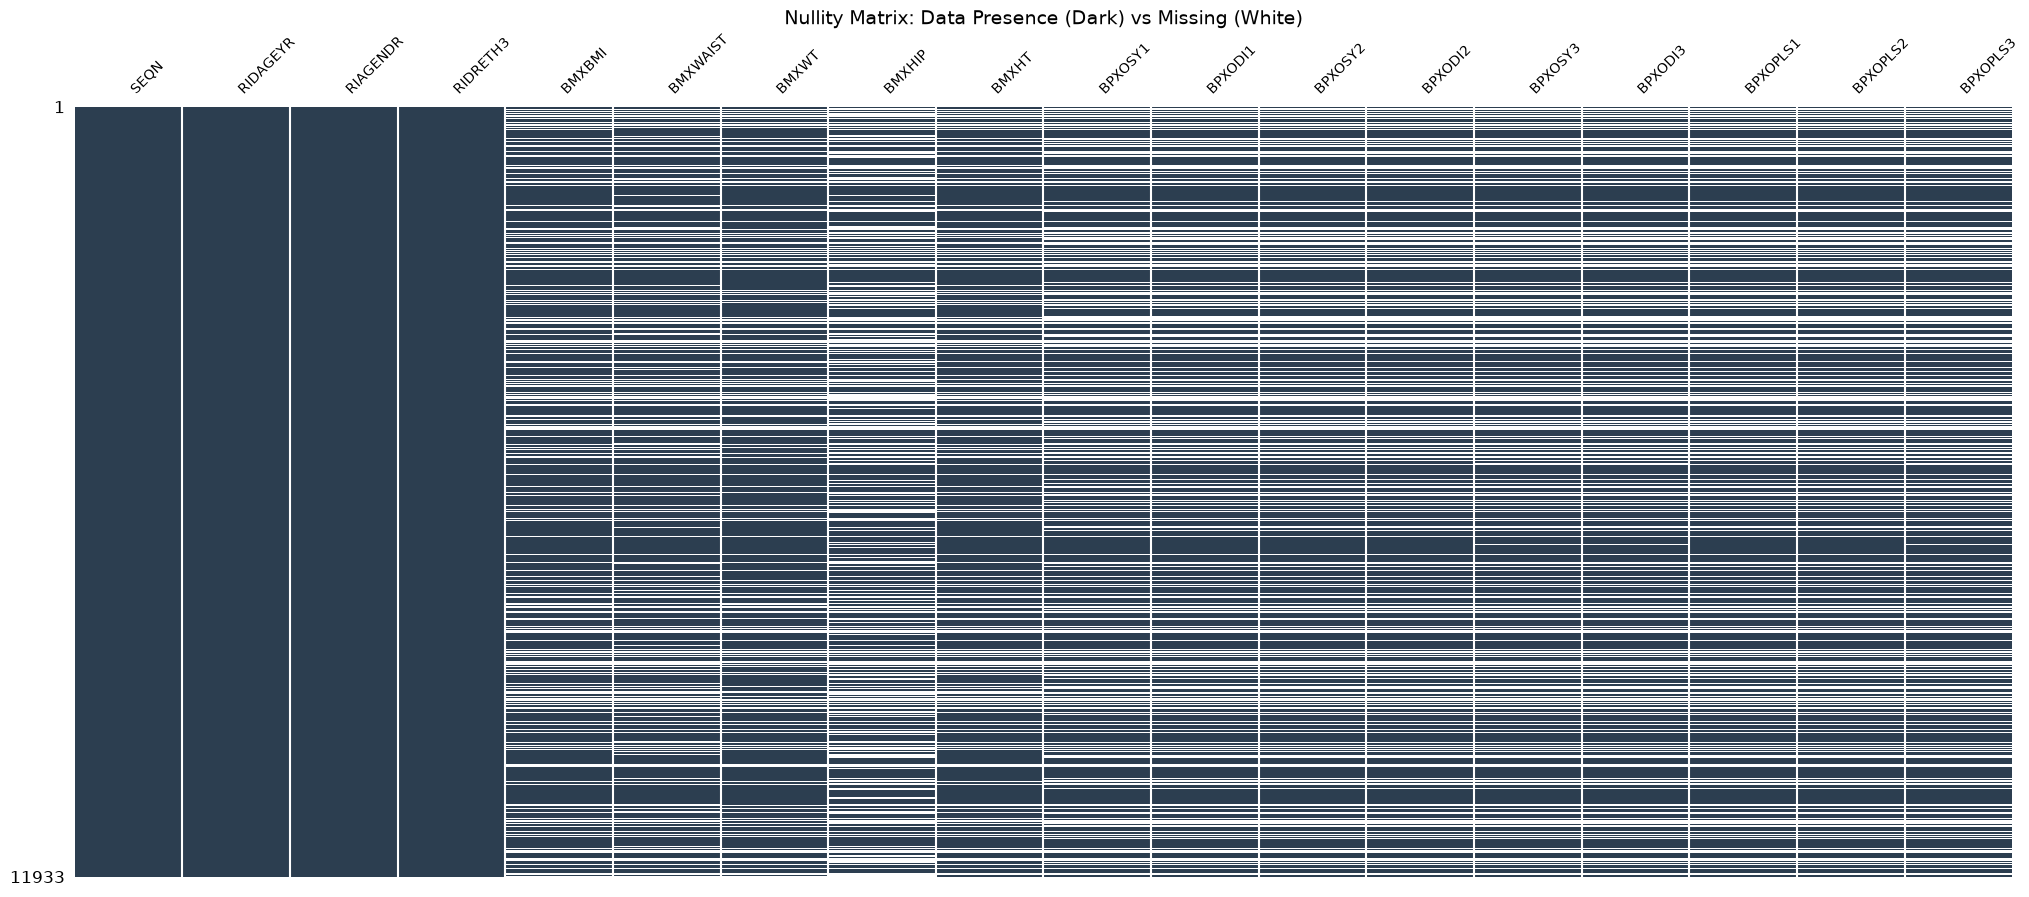

Missingness Visualizations
----------------------------------------


<Figure size 1000x600 with 0 Axes>

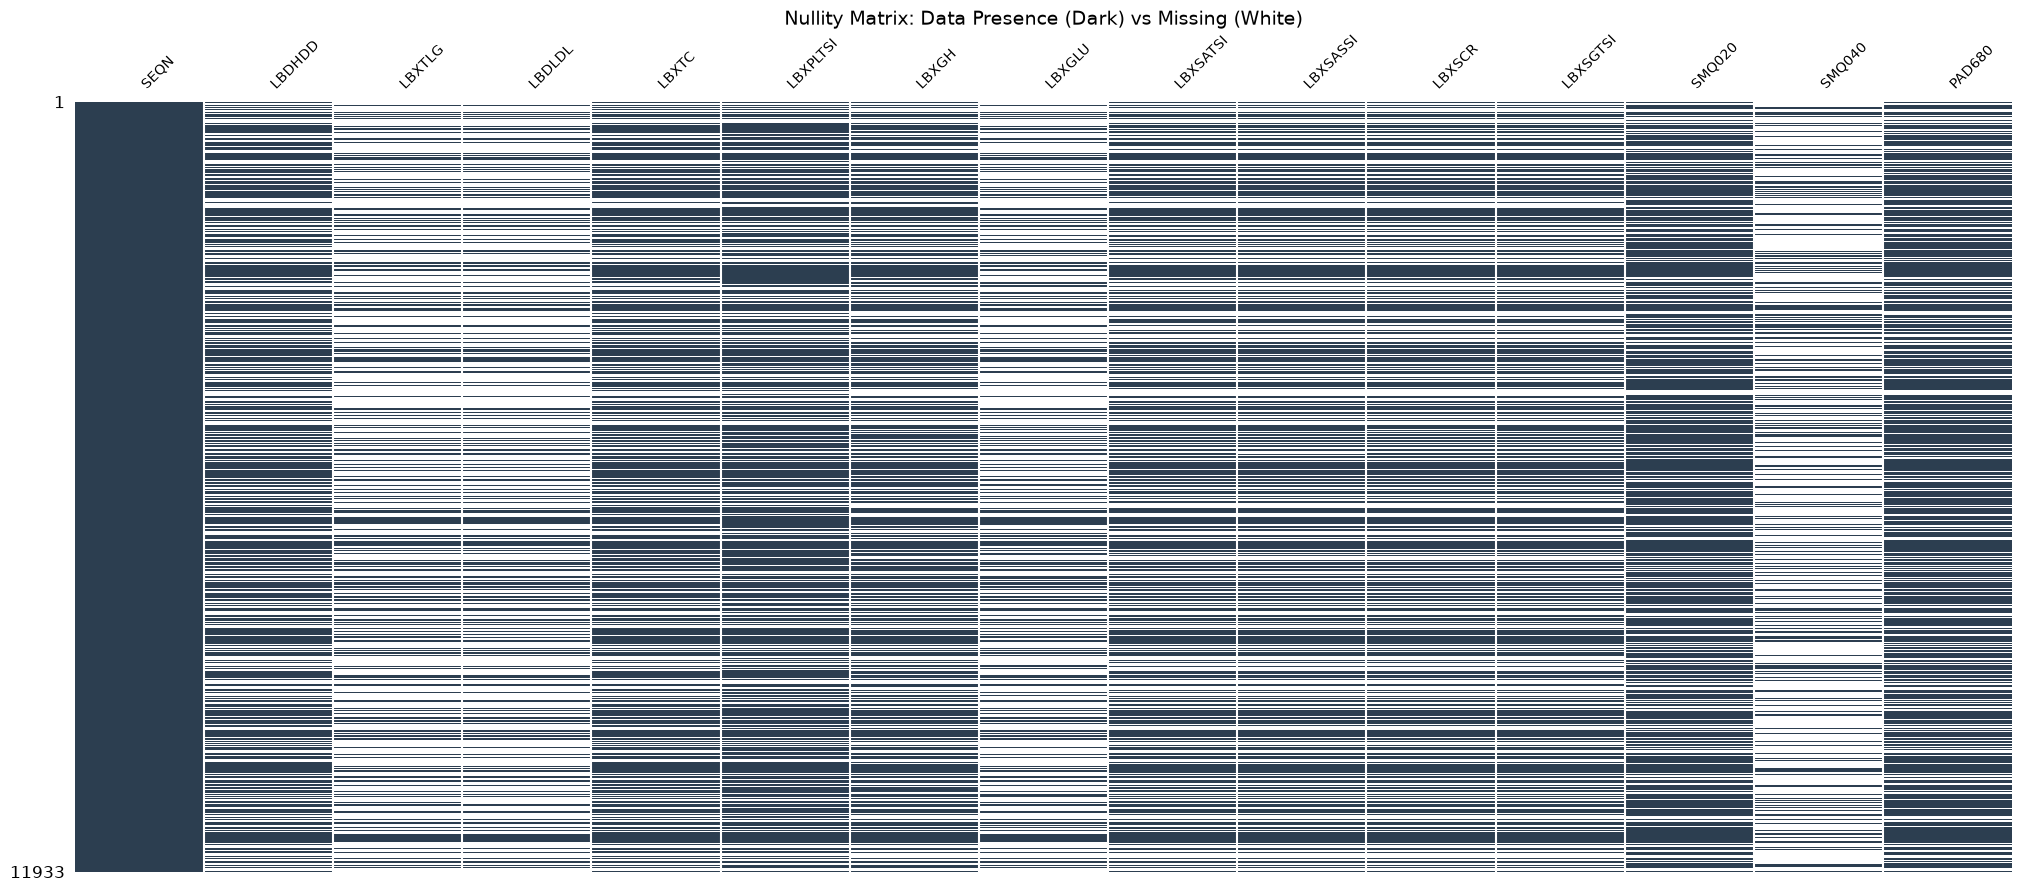

Missingness Visualizations
----------------------------------------


<Figure size 1000x600 with 0 Axes>

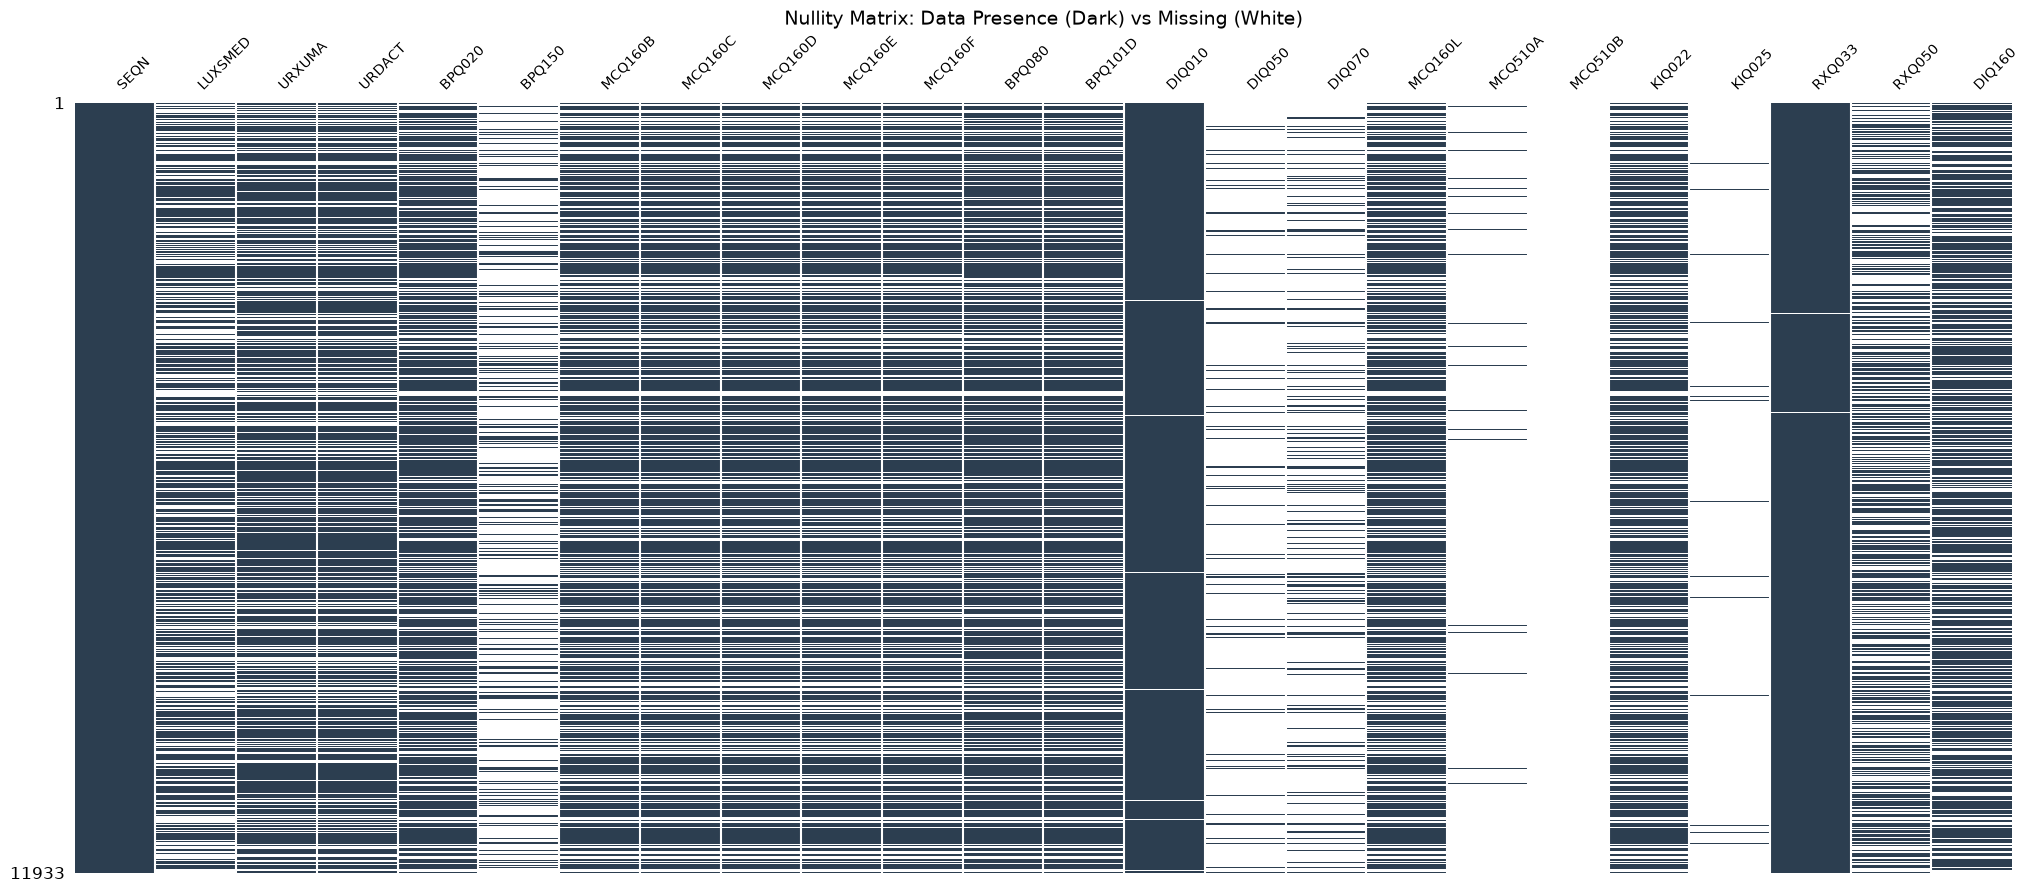

In [51]:
auditor.visualize_nullity(target_columns=demographics)
auditor.visualize_nullity(target_columns=labs_questions)
auditor.visualize_nullity(target_columns=organ_damage)

## 🛠️ Programmatic Optimization via Deterministic Parental Imputation
---
To address these logical skips without introducing artificial bias, we use a custom Python `Imputer` class.

Instead of relying on statistical averages like mean or mode imputation, our `Imputer` applies clinical logic:

$$\text{If } \text{Parent\_Column} \in \text{Trigger\_Value} \implies \text{Child\_Column} \colonequals \text{Logical\_Default}$$

This method programmatically restores structural missingness, preserving key data points for our analysis:

*   **Smoking Profile (`SMQ020`** $\to$ **`SMQ040`):** If a patient has not smoked 100+ cigarettes, their current smoking frequency (`SMQ040`) is programmatically set to `3.0` ("Not at all").
*   **Hypertension Profile (`BPQ020`** $\to$ **`BPQ150`):** If a patient has no history of hypertension, their medication usage (`BPQ150`) is programmatically set to `2.0` ("No").
*   **Diabetes Profile (`DIQ010`** $\to$ **`DIQ050`, `DIQ070`):** If a patient has no history of diabetes, follow-up fields for insulin and oral medication are set to `2.0` ("No").
*   **Hepatic Profile (`MCQ160L`** $\to$ **`MCQ510A`, `MCQ510B`):** If a patient has no history of liver disease, fatty liver and fibrosis flags are resolved to `0.0` (absence of condition).
*   **Renal Profile (`KIQ022`** $\to$ **`KIQ025`):** If a patient has no history of kidney failure, their dialysis history is resolved to `2.0` ("No").

This process ensures that our final cohort remains clean and structurally complete for downstream metabolic modeling.

In [52]:
imputed_dataset = (
    Imputer(selected_columns)
    .structural_skips()
    )

Imputation [SMQ020 -> SMQ040]: Rescued 4878 structural records.
Imputation [BPQ020 -> BPQ150]: Rescued 5518 structural records.
Imputation [DIQ010 -> DIQ050]: Rescued 10655 structural records.
Imputation [DIQ010 -> DIQ070]: Rescued 9455 structural records.
Imputation [MCQ160L -> MCQ510A]: Rescued 7369 structural records.
Imputation [MCQ160L -> MCQ510B]: Rescued 7369 structural records.
Imputation [KIQ022 -> KIQ025]: Rescued 7473 structural records.


## 🩸 Clinical Rationale for the final cohort
---

The final target cohort ($n = 1,955$ working-age adults) is established through a multi-stage epidemiological filtering strategy. Rather than executing a destructive flat subsetting of the dataframe, the pipeline isolates this subpopulation to minimize non-response bias, eliminate structural confounding, and guarantee full data density across our upcoming indices calculations.

- **Fasting Subsample Weighting (WTSAF2YR):** To accurately evaluate the metabolic, lipid, and glycemic vectors of the obesity framework, the cohort is strictly restricted to participants dynamically assigned to the morning fasting subsample who met physiological fasting durations and provided valid blood specimens. Because compliance and non-response patterns for rigorous fasts vary across demographic strata, utilizing the dedicated `WTSAF2YR` weights is epidemiologically mandatory to counteract selection bias and maintain true population representativeness during variance estimation.
- **Physiological Stabilization Filters:**
    - **Pregnancy Status:** Excluding active pregnancies (`RIDEXPRG == 1`) eliminates acute, non-pathological gestational shifts in body composition, lipid metabolism, and insulin sensitivity that would otherwise confound baseline obesity phenotypes.
    - **Age Restraints ($18 \le \text{Age} < 65$):** Restricting the analysis to working-age adults isolates a mature metabolic profile, effectively removing pediatric development variables on the lower bound and minimizing geriatric survivorship bias or competing mortality risks on the upper bound.
- **Feature Completeness for Downstream Index Calculations:** To prevent the introduction of imputation artifacts into our primary risk-scoring frameworks, rows are evaluated for complete-case integrity across all mandatory clinical parameters. This ensures the cohort is fully optimized for the upcoming mathematical calculations, specifically:
    - **AHA PREVENT Equations:** Retaining complete records for the exact cardiovascular-kidney-metabolic (CKM) variables required by the engine (including systolic blood pressure, anti-hypertensive medication histories, smoking status, lipid fractions, and eGFR).
    - **Cardiometabolic & Obesity Phenotyping:** Ensuring zero missingness among the baseline anthropometric and biochemical components required to calculate composite metabolic markers (e.g., METS-IR, TyG index).

![Cohort flowchart](../assets/cohort_flowchart.svg)


In [53]:
final_df = (
    Processor(imputed_dataset)
    .inclusion_criteria()
    .get_data()
)

Starting rows: 11933 active records.
Exclusion [Fasting]: Dropped 7937 active records.
Exclusion [Pregnancy]: Dropped 28 active records.
Exclusion [Age boundaries]: Dropped 1587 active records.
Exclusion [Missing variables]: Dropped 426 active records.
Final Cohort Size: 1955 active records.


In [54]:
selected_cohort = final_df[final_df["cohort"] == 1]

In [55]:
# Instantiate the audit engine by explicitly passing your data and loader metadata
auditor = Auditor(selected_cohort, metadata_storage=loader.metadata_storage)

# Run the execution layer and capture the full dataframe output
missing_data_summary = auditor.column_missingness(head_count= 20)

,Variable_Code,Clinical_Label,Missing_Count,Missing_Percentage
0,RIDEXPRG,Pregnancy status at exam,1451,74.219949
1,RXQ050,Number of prescription medicines taken,792,40.511509
2,DIQ160,Ever told you have prediabetes,247,12.634271
3,MCQ510B,Liver condition: Liver fibrosis,202,10.332481
4,MCQ510A,Liver condition: Fatty liver,142,7.263427
5,MCQ160F,Ever told you had a stroke,101,5.166240
6,MCQ160C,Ever told you had coronary heart disease,100,5.115090
7,MCQ160E,Ever told you had heart attack,100,5.115090
8,KIQ025,Received dialysis in past 12 months?,100,5.115090
9,KIQ022,Ever told you had weak/failing kidneys?,99,5.063939


Missingness Visualizations
----------------------------------------


<Figure size 1000x600 with 0 Axes>

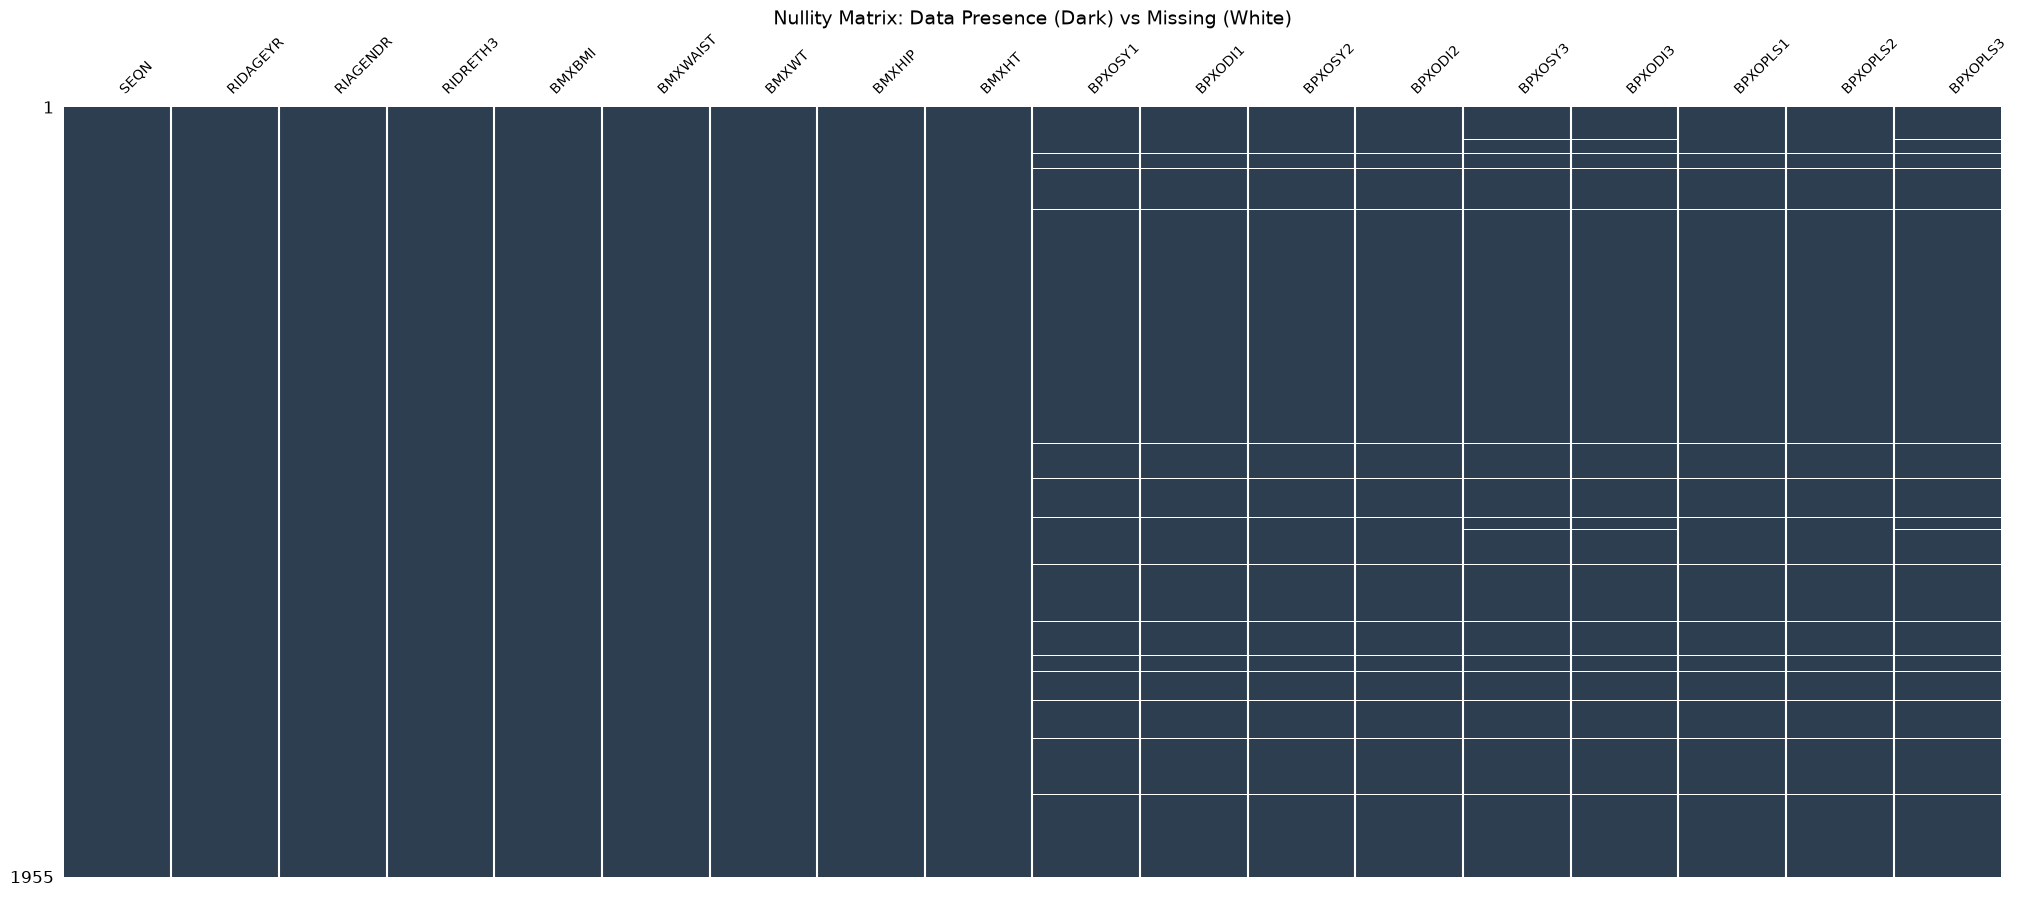

Missingness Visualizations
----------------------------------------


<Figure size 1000x600 with 0 Axes>

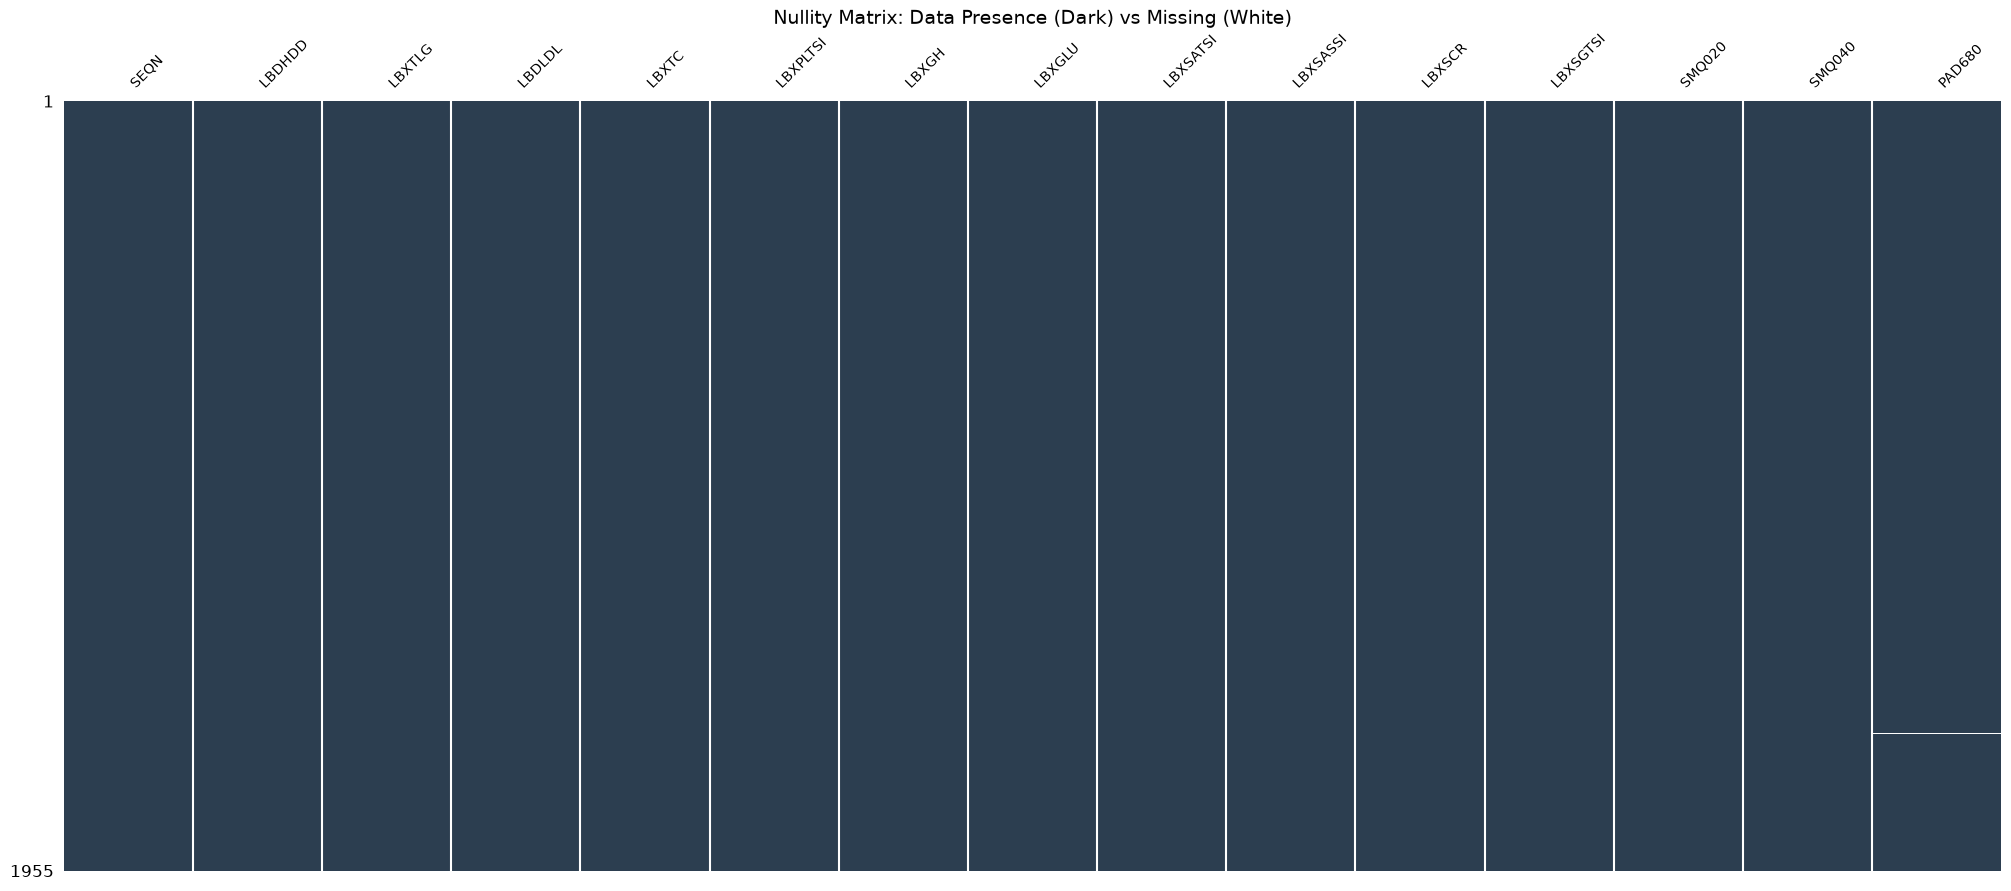

Missingness Visualizations
----------------------------------------


<Figure size 1000x600 with 0 Axes>

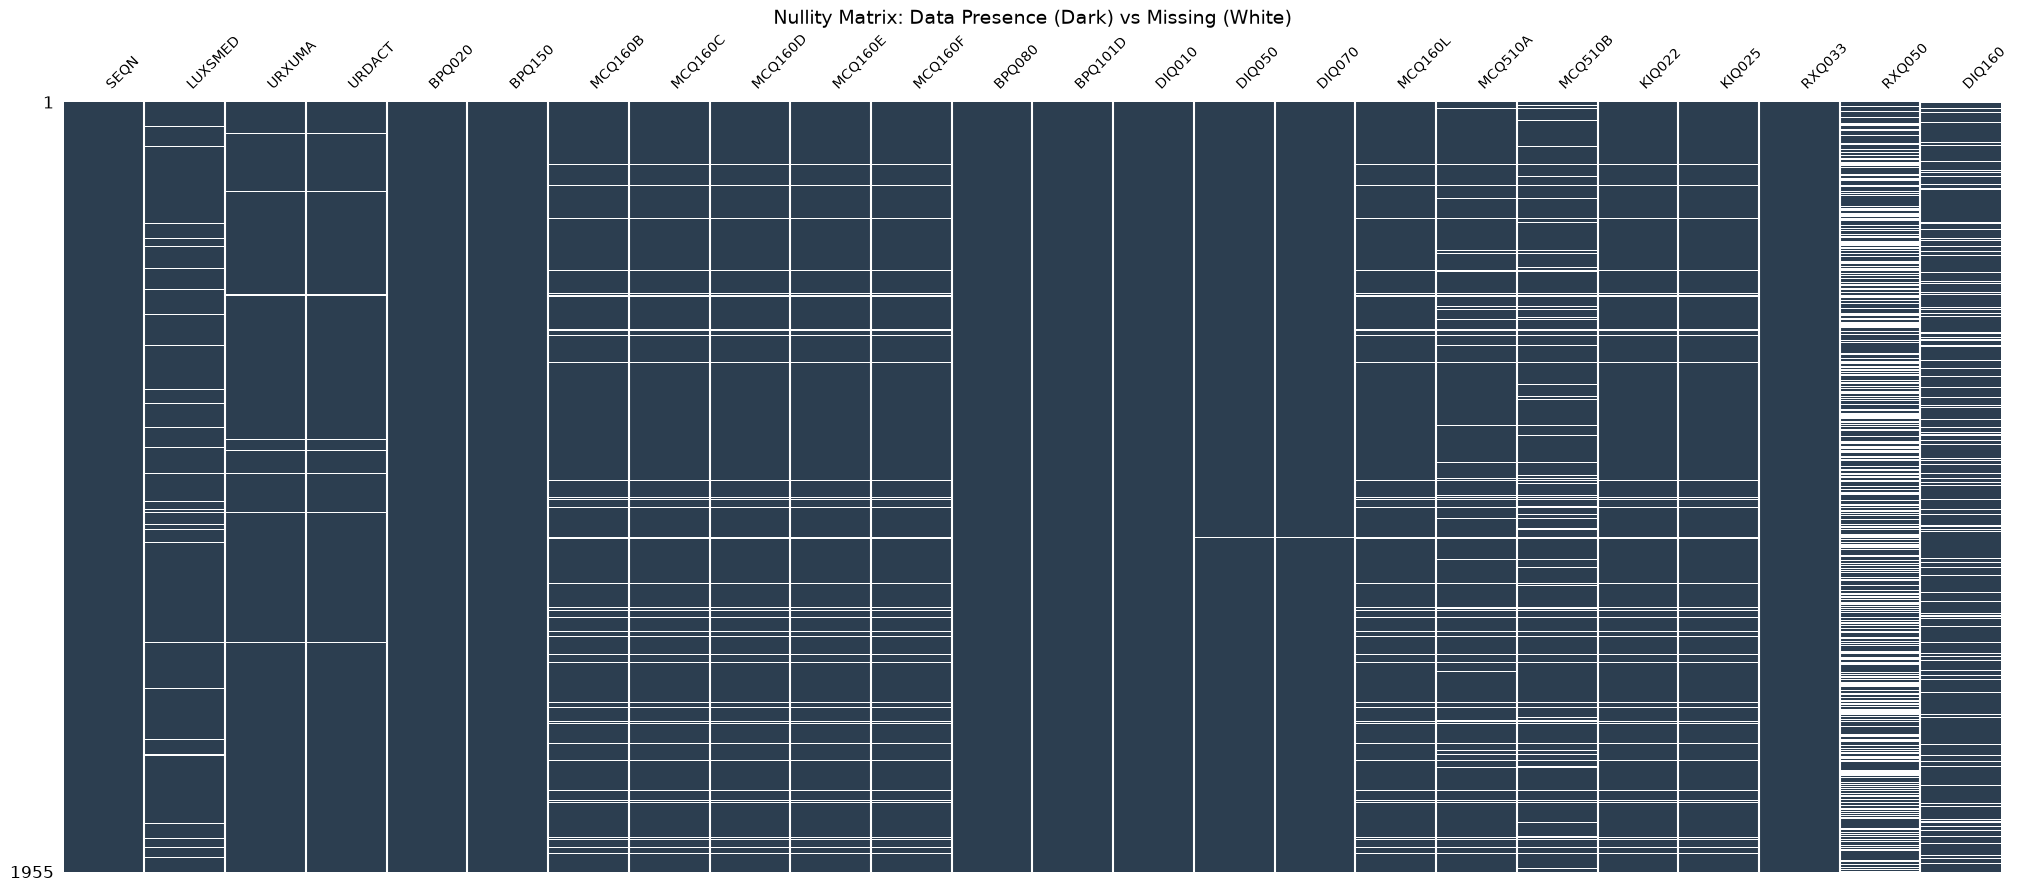

In [56]:
auditor.visualize_nullity(target_columns=demographics)
auditor.visualize_nullity(target_columns=labs_questions)
auditor.visualize_nullity(target_columns=organ_damage)

In [57]:
# NHANES metadata map directly inside the dataframe attributes
final_df.attrs['clinical_metadata'] = loader.metadata_storage

In [58]:
# Export the cohort while embedding the metadata
final_df.to_parquet(
    '../outputs/nhanes_prepared_cohort.parquet', 
    engine='pyarrow', 
    compression='snappy'
)

In [59]:
# Load the dataset back into memory
loaded_df = pd.read_parquet('../outputs/nhanes_processed_cohort.parquet')

# Extract and inspect your clinical label mapping
saved_metadata = loaded_df.attrs.get('clinical_metadata')

# Quick test to see it worked
print(type(saved_metadata))  # Output: <class 'dict'>

<class 'dict'>
